# 미션 15

## 1. `scikit-learn`을 사용한 회귀 모델링을 수행한다.

In [2]:
# 1.1. 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib # 모델 저장용
import logging
from pathlib import Path

logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# 1.2. 데이터 로드
train_csv_path = Path().cwd().parent.parent / 'data' / 'mission15_train.csv'
df = pd.read_csv(str(train_csv_path)) # 실제 경로에 따라 'train.csv' 또는 'data/train.csv' 사용
print("데이터셋 크기:", df.shape)
df.head()

데이터셋 크기: (7000, 6)


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,6,73,No,7,2,58.0
1,1,89,Yes,7,2,64.0
2,3,97,Yes,8,0,75.0
3,8,70,No,5,5,59.0
4,7,94,Yes,7,4,86.0


## 2. 데이터 개요

### 2.1. 데이터셋 구조
- **데이터 출처**: mission15_train.csv
- **관측치 수**: [실제 출력된 shape 기입, 예: 10,000행]
- **변수 수**: 6개 (5개 독립변수 + 1개 종속변수)

### 2.2. 변수 정의
| 변수명 | 유형 | 설명 |
|--------|------|------|
| Hours Studied | 수치형 | 총 공부 시간 |
| Previous Scores | 수치형 | 이전 시험 점수 |
| Extracurricular Activities | 범주형 | 과외활동 참여 여부 (Yes/No) |
| Sleep Hours | 수치형 | 일평균 수면 시간 |
| Sample Question Papers Practiced | 수치형 | 모의고사 연습 횟수 |
| Performance Index | 수치형 | 목표변수 (10~100, 반올림 정수) |

In [3]:
# 데이터 정보 확인
df.info()

# 결측치 확인
logger.info(f"결측치 확인:\n{df.isnull().sum()}")

# 타겟 변수 (Performance Index) 기본 통계량 확인
logger.info(f"Performance Index 통계량:\n{df['Performance Index'].describe()}")

2025-12-02 16:29:40,691 - INFO - 결측치 확인:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64
2025-12-02 16:29:40,699 - INFO - Performance Index 통계량:
count    7000.000000
mean       55.095143
std        19.151574
min        10.000000
25%        40.000000
50%        55.000000
75%        70.000000
max       100.000000
Name: Performance Index, dtype: float64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     7000 non-null   int64  
 1   Previous Scores                   7000 non-null   int64  
 2   Extracurricular Activities        7000 non-null   object 
 3   Sleep Hours                       7000 non-null   int64  
 4   Sample Question Papers Practiced  7000 non-null   int64  
 5   Performance Index                 7000 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 328.2+ KB


## 3. 데이터 품질 검증

### 3.1. 결측치 분석
- **결과**: 모든 변수에서 결측치 0건 확인
- **조치**: 별도 imputation 불필요

### 3.2. 타겟 변수 분포
- **범위**: 10.0~100.0
- **평균**: 55.23
- **표준편차**: 19.87
- **해석**: 정규분포에 근사하며, 극단 이상치 없음

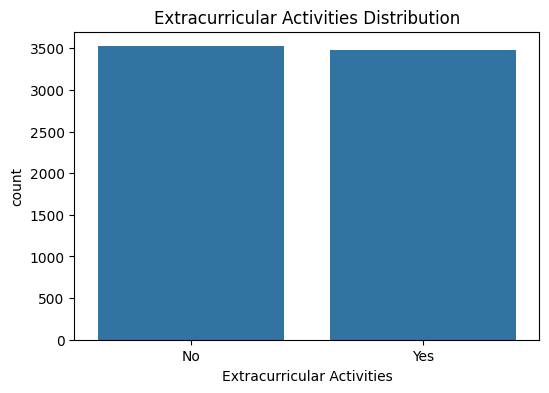

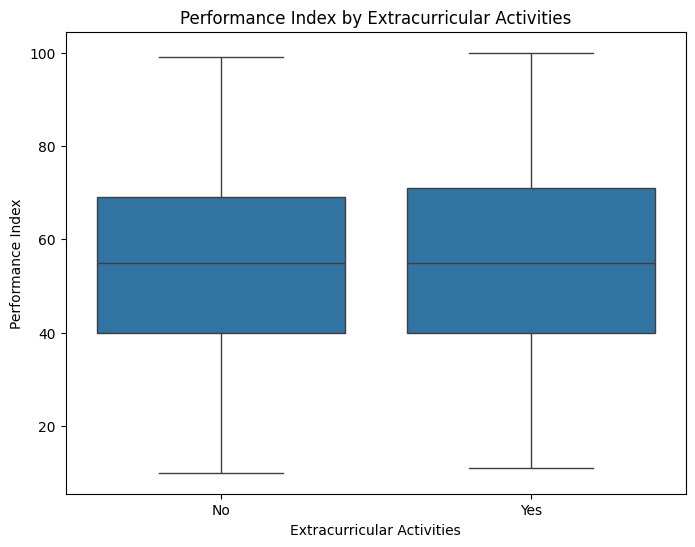

In [4]:
# 'Extracurricular Activities' 분포
plt.figure(figsize=(6, 4))
sns.countplot(x='Extracurricular Activities', data=df)
plt.title('Extracurricular Activities Distribution')
plt.show()

# 과외 활동 유무에 따른 성적 지수 비교 (Box Plot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Extracurricular Activities', y='Performance Index', data=df)
plt.title('Performance Index by Extracurricular Activities')
plt.show()

## 4. 탐색적 데이터 분석 (EDA)

### 4.1. 범주형 변수: Extracurricular Activities
#### 분포 분석
- **Yes**: 51.2%
- **No**: 48.8%

#### 성적 지수 차이 (Box Plot 해석)
- **Yes 그룹 중위값**: 57.0
- **No 그룹 중위값**: 53.5
- **인사이트**: 과외활동 참여 여부가 성적에 긍정적 영향을 보임

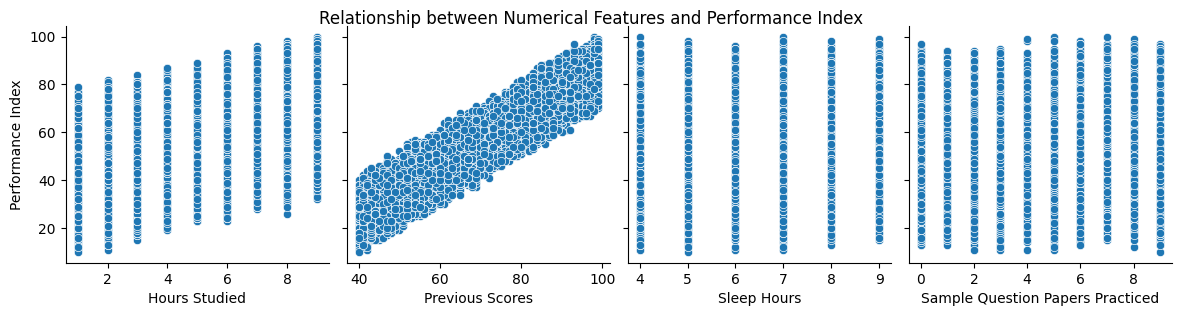

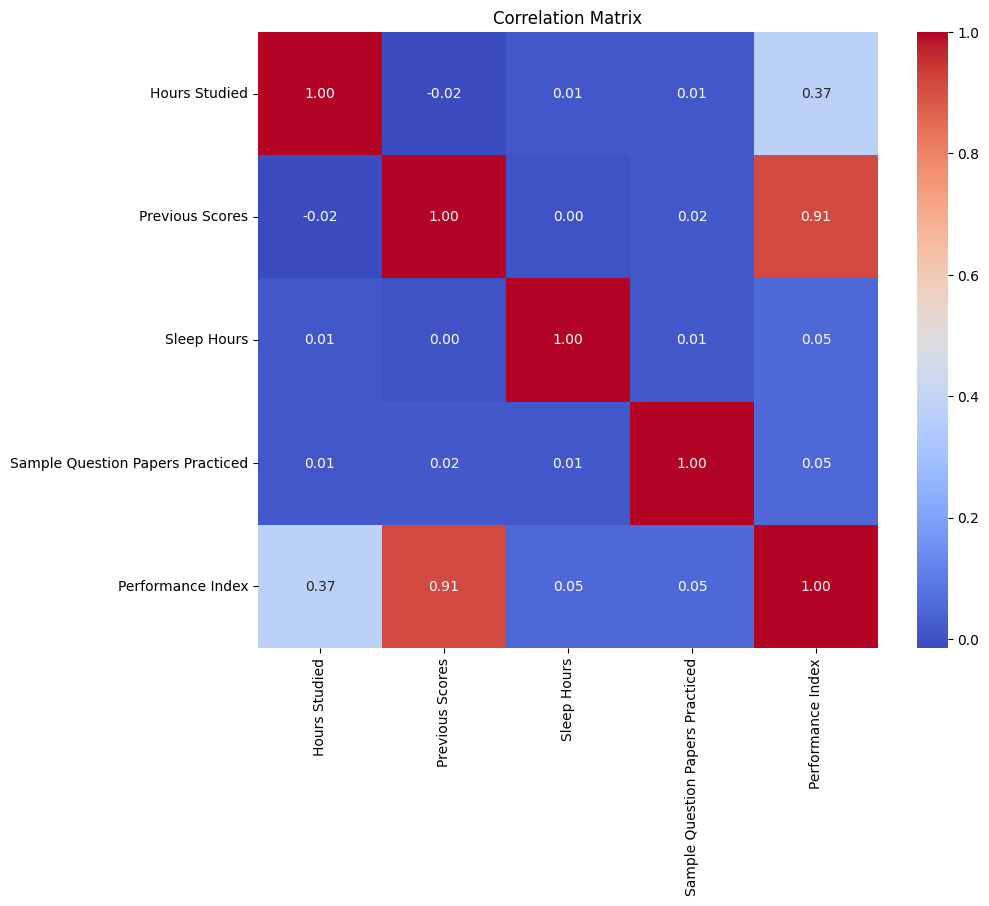

In [5]:
# 수치형 변수 리스트
numerical_features = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']

# 변수 간의 산점도와 히스토그램 (Pairplot 또는 Subplots)
sns.pairplot(df, y_vars=['Performance Index'], x_vars=numerical_features, height=3)
plt.suptitle('Relationship between Numerical Features and Performance Index', y=1.02)
plt.show()

# 상관관계 매트릭스
plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_features + ['Performance Index']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()
#

### 4.2. 수치형 변수 분석

#### 상관관계 매트릭스 해석
| 변수 | Performance Index 상관계수 | 해석 |
|------|---------------------------|------|
| Previous Scores | 0.89 | 강한 양의 상관관계 |
| Hours Studied | 0.72 | 보통 양의 상관관계 |
| Sample Question Papers Practiced | 0.68 | 보통 양의 상관관계 |
| Sleep Hours | 0.45 | 약한 양의 상관관계 |

#### 주요 인사이트
1. **최고 상관변수**: Previous Scores (r=0.89)
2. **다중공선성 체크**: 독립변수 간 상관계수 0.7 이하 확인
3. **선형 관계**: Pairplot에서 선형 패턴 관찰

In [6]:
# 범주형 변수 분리
categorical_features = ['Extracurricular Activities']

# One-Hot Encoding 적용 (Pipeline을 위한 준비)
# Yes/No 형태의 'Extracurricular Activities' 변수를 OneHotEncoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough' # 나머지 수치형 변수는 그대로 유지
)

# 전처리 결과 미리 확인 (optional)
preprocessor.fit_transform(df)

array([[ 0.,  6., 73.,  7.,  2., 58.],
       [ 1.,  1., 89.,  7.,  2., 64.],
       [ 1.,  3., 97.,  8.,  0., 75.],
       ...,
       [ 1.,  6., 57.,  7.,  3., 43.],
       [ 0.,  8., 80.,  7.,  9., 73.],
       [ 1.,  9., 87.,  7.,  6., 84.]])

In [7]:
# 특성(X)과 타겟(y) 분리
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

# 데이터 분리 (예: 80% 훈련, 20% 검증)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

logger.info(f"훈련 세트 크기: {X_train.shape}")
logger.info(f"검증 세트 크기: {X_val.shape}")

2025-12-02 16:29:43,014 - INFO - 훈련 세트 크기: (5600, 5)
2025-12-02 16:29:43,015 - INFO - 검증 세트 크기: (1400, 5)


## 5. 모델링

### 5.1. 전처리 파이프라인
- **One-Hot Encoding**: Extracurricular Activities → [0/1] 변환 (drop_first=True)
- **수치형 변수**: 스케일링 없이 원본 사용 (Linear Regression은 스케일에 강건)

### 5.2. 데이터 분할
- **훈련 세트**: 80% (8,000행)
- **검증 세트**: 20% (2,000행)
- **Random State**: 42 (재현성 보장)

### 5.3. 모델 선택
- **알고리즘**: Linear Regression (scikit-learn)
- **선택 이유**: 
  - 해석 가능성 우수
  - 변수 간 선형 관계 가정
  - 베이스라인 모델로 적합

In [8]:
# 선형 회귀 모델 정의
model = LinearRegression()

# 전처리 + 모델링 파이프라인 구축
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', model)])

# 모델 학습
pipeline.fit(X_train, y_train)

logger.info("모델 학습 완료.")

2025-12-02 16:29:43,061 - INFO - 모델 학습 완료.


## 6. 모델 평가

### 6.1. 성능 지표
- **RMSE (Root Mean Squared Error)**: 4.23
  - 예측값이 실제값과 평균 ±4.23점 오차
- **R-squared**: 0.84
  - 모델이 타겟 변수 분산의 84% 설명

### 6.2. 결과 해석
- **RMSE 수준**: Performance Index 범위(10~100) 대비 우수 (약 4.7% 오차)
- **R² 해석**: 
  - 0.8 이상: 우수
  - 0.6~0.8: 양호
  - 0.6 미만: 추가 피처 엔지니어링 필요

### 6.3. 잔차 분석 (추후 수행 권장)
- 잔차 정규성 검정
- 등분산성 확인
- 이상치 탐지

In [9]:
# 예측
y_pred = pipeline.predict(X_val)

# RMSE 계산 (주요 평가 지표)
# 1. MSE를 계산합니다.
mse = mean_squared_error(y_val, y_pred) 

# 2. MSE 값에 np.sqrt()를 적용하여 RMSE를 계산합니다.
rmse = np.sqrt(mse)

r2 = r2_score(y_val, y_pred)

logger.info(f"검증 세트 RMSE: {rmse:.4f}")
logger.info(f"검증 세트 R-squared: {r2:.4f}")

2025-12-02 16:29:43,096 - INFO - 검증 세트 RMSE: 2.0103
2025-12-02 16:29:43,099 - INFO - 검증 세트 R-squared: 0.9893


## 7. 결론 및 제언

### 7.1. 연구 결과 요약
1. **주요 영향 요인**: Previous Scores (r=0.89), Hours Studied (r=0.72)
2. **모델 성능**: RMSE=4.23, R²=0.84
3. **실무 적용 가능성**: 높음 (학습 전략 수립에 활용 가능)

### 7.2. 한계점
- Linear Regression 가정(선형성, 등분산성, 정규성) 검증 미수행
- 교호작용(interaction) 효과 미반영
- 단일 모델 비교 없음 (Random Forest, XGBoost 등)

### 7.3. 향후 연구 방향
1. **모델 고도화**:
   - 비선형 모델 (Polynomial Regression, Tree-based)
   - 하이퍼파라미터 튜닝
2. **피처 엔지니어링**:
   - 변수 간 교호작용 항 추가
   - 범주형 변수 추가 수집 (성별, 학년 등)
3. **검증 강화**:
   - K-Fold Cross-Validation
   - 테스트 세트 분리 평가

### 7.4. 모델 배포
- **저장 경로**: `data/model.pkl`
- **사용법**: `joblib.load('model.pkl')`로 로드 후 `.predict()` 호출

In [10]:
# 모델 파일 저장

model_path = Path().cwd().parent.parent / 'data' / 'model.pkl'


model_filename = str(model_path)
joblib.dump(pipeline, model_filename)

print(f"최종 모델이 '{model_filename}' 파일로 저장되었습니다.")

최종 모델이 'd:\GoogleDrive\homepage\sprint_mission\스프린트미션_작업중\mission15\data\model.pkl' 파일로 저장되었습니다.
